In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
import gc

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgbm
from catboost import CatBoostClassifier
import xgboost as xgb

from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

N_THREADS = 12  #nombre de coeurs de la machine


In [2]:
X_train = pd.read_csv('X_train.csv', index_col='ROW_ID')
X_test = pd.read_csv('X_test.csv', index_col='ROW_ID') 

y_train = pd.read_csv('y_train.csv', index_col='ROW_ID')
sample_submission = pd.read_csv('sample_submission.csv', index_col='ROW_ID')


### Réduction de l'empreinte mémoire (downcast float64 → float32)

Toutes les colonnes numériques de `X_train`/`X_test` ainsi que `target` sont converties
de `float64` vers `float32`, pour prendre 2 fois moins d'espace mémoire sans impacter la performance.
Cela réduit le risque de `MemoryError` sur l'ensemble du pipeline.

In [3]:
float_cols_train = X_train.select_dtypes(include='float64').columns
float_cols_test = X_test.select_dtypes(include='float64').columns
X_train[float_cols_train] = X_train[float_cols_train].astype(np.float32)
X_test[float_cols_test] = X_test[float_cols_test].astype(np.float32)

y_train['target'] = y_train['target'].astype(np.float32)


In [4]:
X_train.columns

Index(['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16',
       'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9',
       'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1',
       'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP'],
      dtype='object')

In [5]:
RET_features = [f'RET_{i}' for i in range(1, 21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']


### Sanity checks (EDA rapide)

**Fonctionnement :** on vérifie l'équilibre du target et la proportion de valeurs manquantes par colonne.

**Utilité :** si le target n'est pas équilibré 50/50, le seuil de décision à 0.5 et l'interprétation brute
de l'accuracy peuvent être trompeurs.

**Apport au projet :** oriente l'interprétation des scores d'accuracy obtenus plus loin, et motive la
calibration de seuil mise en place à la fin du notebook.

In [6]:
print("Distribution du target (train) :")
print((y_train['target'] > 0).value_counts(normalize=True))

print("\nProportion de NaN par colonne brute :")
print(X_train.isna().mean().sort_values(ascending=False).head(10))


Distribution du target (train) :
target
True     0.507184
False    0.492816
Name: proportion, dtype: float64

Proportion de NaN par colonne brute :
SIGNED_VOLUME_1          0.735204
SIGNED_VOLUME_20         0.016123
MEDIAN_DAILY_TURNOVER    0.006902
SIGNED_VOLUME_19         0.005696
SIGNED_VOLUME_18         0.001630
RET_20                   0.000110
SIGNED_VOLUME_17         0.000110
SIGNED_VOLUME_16         0.000095
RET_19                   0.000095
SIGNED_VOLUME_15         0.000080
dtype: float64


### Baselines naïves (sans modèle)

Avant tout modèle, on vérifie ce que donnent des règles déterministes triviales. Elles n'ont aucun
paramètre appris (pas de risque d'overfitting), donc on peut les évaluer directement sur tout `X_train`
sans cross-validation.

**Fonctionnement :** on calcule l'accuracy de 4 règles simples — classe majoritaire, persistance du signe
d'hier, momentum 5j et 20j.

**Utilité :** point de repère pour juger si le machine learning apporte vraiment quelque chose au-delà du
signal évident.

**Apport au projet :** ces scores sont réintégrés dans le tableau de comparaison final (`experiment_log`),
pour calibrer les attentes sur tous les modèles.

In [7]:
y_true = (y_train['target'] > 0).astype(int)

majority_class_acc = max(y_true.mean(), 1 - y_true.mean())
persist_acc = accuracy_score(y_true, (X_train['RET_1'] > 0).astype(int))
momentum5_acc = accuracy_score(y_true, (X_train[RET_features[:5]].mean(1) > 0).astype(int))
momentum20_acc = accuracy_score(y_true, (X_train[RET_features[:20]].mean(1) > 0).astype(int))

naive_baselines = {
    'naive_majority_class': majority_class_acc * 100,
    'naive_persistence_RET1': persist_acc * 100,
    'naive_momentum_5j': momentum5_acc * 100,
    'naive_momentum_20j': momentum20_acc * 100,
}

for k, v in naive_baselines.items():
    print(f"{k}: {v:.2f}%")


naive_majority_class: 50.72%
naive_persistence_RET1: 51.89%
naive_momentum_5j: 50.56%
naive_momentum_20j: 50.82%


### À propos de `GROUP` : pourquoi on l'abandonne

**Le principe de départ.** `GROUP` est un identifiant anonymisé regroupant des allocations qui partagent
probablement une caractéristique commune (famille de stratégies, classe d'actifs...). L'idée testée était
que le comportement récent des *autres* allocations du même groupe pourrait aider à prédire le signe d'une
allocation donnée — par trois approches : (1) `GROUP` comme variable catégorielle brute, laissant le modèle
apprendre un éventuel effet propre à chaque groupe ; (2) des agrégats du groupe (moyenne de performance et
de volatilité des pairs, en excluant l'allocation elle-même) ; (3) la position relative de l'allocation par
rapport à son groupe (écart et rang percentile).

**Ce qu'on a observé.** Sur les trois familles de modèles testées (LightGBM, CatBoost, XGBoost), ajouter
ces features de `GROUP` à la configuration de base n'apportait **aucun gain significatif** — et déteriorait
même très légèrement l'accuracy dans la plupart des cas, de façon cohérente sur les trois modèles. CatBoost,
dont l'encodage natif des catégories est pourtant plus sophistiqué que celui de LightGBM, ne faisait pas
mieux non plus. Les écarts observés étaient systématiquement plus petits que l'écart-type d'une config
individuelle entre folds — un signe classique de bruit de mesure plutôt que d'un vrai signal.

**Pourquoi on les retire.** Continuer à transporter ces features ne ferait qu'ajouter du bruit et de la
complexité (calcul, mémoire, risque d'overfitting) sans bénéfice mesurable. On simplifie donc le pipeline en
ne gardant qu'un seul jeu de features (plus besoin de comparer plusieurs configurations), ce qui libère du
temps de calcul pour explorer d'autres pistes plus prometteuses (liquidité, forme des rendements, voir plus
bas) et pour le tuning d'hyperparamètres / le stacking mis en place en fin de notebook.

### Harmonisation des catégories (plus nécessaire)

Cette étape existait uniquement pour garantir un encodage cohérent de `GROUP` entre train et test. `GROUP`
n'étant plus utilisé comme feature, elle est supprimée : aucune colonne catégorielle n'est plus transmise
aux modèles dans ce notebook.

#### Feature engineering principal : momentum, volatilité, effet marché

**Fonctionnement :** pour chaque horizon (3, 5, 10, 15, 20 jours), on calcule la moyenne des rendements
passés de l'allocation (`AVERAGE_PERF_i`) et la moyenne de ce même indicateur sur **toutes les allocations
de la même date** (`ALLOCATIONS_AVERAGE_PERF_i`, effet marché global). On fait de même pour la volatilité
(écart-type) sur 20 jours.

**Utilité :** distingue le signal propre à une allocation (momentum individuel) du signal partagé par tout
le marché (effet de régime).

**Apport au projet :** ce sont les features du benchmark original — le socle sur lequel viennent se greffer
toutes les nouvelles features ci-dessous.

In [8]:
for i in [3, 5, 10, 15, 20]:
    X_train[f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')

    X_test[f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
    X_test[f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    X_train[f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(1)
    X_train[f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[f'STD_PERF_{i}'].transform('mean')

    X_test[f'STD_PERF_{i}'] = X_test[RET_features[:i]].std(1)
    X_test[f'ALLOCATIONS_STD_PERF_{i}'] = X_test.groupby('TS')[f'STD_PERF_{i}'].transform('mean')


#### Features de liquidité, ratio perf/vol, interactions, forme de la distribution

**Fonctionnement :** on étend le feature engineering à `SIGNED_VOLUME` (moyennes par horizon + effet
marché, comme pour les rendements). On ajoute un ratio performance/volatilité (`SHARPE_PERF_i`), une
interaction turnover × volatilité (`TURNOVER_X_VOL`), la skewness/kurtosis des 20 derniers rendements, et
une corrélation ligne par ligne entre rendement et volume signé (`CORR_RET_VOLUME_20`, vectorisée en
numpy).

**Utilité :** le benchmark original n'exploitait ni `SIGNED_VOLUME` ni `MEDIAN_DAILY_TURNOVER` au-delà de
leur valeur brute — ces features cherchent à capter la conviction du marché et la stabilité du couple
rendement/risque.

**Apport au projet :** c'est la piste de feature engineering la plus prometteuse identifiée après avoir
écarté `GROUP`.

In [9]:
eps = 1e-8

for i in [3, 5, 10, 15, 20]:
    for df in [X_train, X_test]:
        df[f'AVERAGE_SIGNED_VOLUME_{i}'] = df[SIGNED_VOLUME_features[:i]].mean(1)
        df[f'ALLOCATIONS_AVERAGE_SIGNED_VOLUME_{i}'] = (
            df.groupby('TS')[f'AVERAGE_SIGNED_VOLUME_{i}'].transform('mean')
        )

volume_features = (
    [f'AVERAGE_SIGNED_VOLUME_{i}' for i in [3, 5, 10, 15, 20]]
    + [f'ALLOCATIONS_AVERAGE_SIGNED_VOLUME_{i}' for i in [3, 5, 10, 15, 20]]
)

for i in [5, 10, 20]:
    for df in [X_train, X_test]:
        df[f'SHARPE_PERF_{i}'] = df[f'AVERAGE_PERF_{i}'] / (df['STD_PERF_20'] + eps)

sharpe_features = [f'SHARPE_PERF_{i}' for i in [5, 10, 20]]

for df in [X_train, X_test]:
    df['TURNOVER_X_VOL'] = df['MEDIAN_DAILY_TURNOVER'] * df['STD_PERF_20']

interaction_features = ['TURNOVER_X_VOL']

for df in [X_train, X_test]:
    df['SKEW_PERF_20'] = df[RET_features].skew(axis=1)
    df['KURT_PERF_20'] = df[RET_features].kurt(axis=1)

shape_features = ['SKEW_PERF_20', 'KURT_PERF_20']


def rowwise_corr(df, cols_a, cols_b):
    """Correlation de Pearson calculee ligne par ligne entre deux blocs de colonnes."""
    A = df[cols_a].to_numpy(dtype=float)
    B = df[cols_b].to_numpy(dtype=float)
    A_centered = A - A.mean(axis=1, keepdims=True)
    B_centered = B - B.mean(axis=1, keepdims=True)
    num = (A_centered * B_centered).sum(axis=1)
    den = np.sqrt((A_centered ** 2).sum(axis=1) * (B_centered ** 2).sum(axis=1))
    return np.divide(num, den, out=np.zeros_like(num), where=den != 0)


for df in [X_train, X_test]:
    df['CORR_RET_VOLUME_20'] = rowwise_corr(df, RET_features, SIGNED_VOLUME_features)

corr_features = ['CORR_RET_VOLUME_20']

new_engineered_features = volume_features + sharpe_features + interaction_features + shape_features + corr_features


#### Nouvelles features (v2) : EWMA, volatilité relative, choppiness, drawdown, z-score, volume/turnover, accélération

**Fonctionnement :**
- `EWMA_PERF_HLh` : moyenne pondérée exponentiellement des rendements (poids décroissant avec l'ancienneté,
  demi-vie `h` jours) — plus réactive au tout dernier signal qu'une moyenne simple.
- `VOL_RATIO_RECENT_OLD` : ratio volatilité des 10 derniers jours / volatilité des 10 jours précédents —
  détecte un régime de volatilité qui s'accélère ou se calme.
- `SIGN_CHANGES_20` : nombre de changements de signe sur 20 jours — proxy de "choppiness" (marché erratique)
  vs tendance claire.
- `MAX_DRAWDOWN_20` : perte maximale depuis un sommet, calculée sur le chemin de richesse cumulée des 20
  derniers jours (en ordre chronologique) — capture un risque de queue invisible pour la moyenne/l'écart-type.
- `VOL_DRAG_20` : écart entre rendement arithmétique moyen et rendement géométrique réel — plus la
  volatilité est élevée, plus cet écart ("volatility drag") est important, à performance moyenne égale.
- `ZSCORE_RET1` : le dernier rendement connu, normalisé par la volatilité historique de l'allocation — un
  choc est-il extrême par rapport à son propre historique ?
- `VOLUME_PER_TURNOVER` : liquidité moyenne rapportée au rythme de rebalancement.
- `MOMENTUM_ACCEL` : écart entre momentum court terme (3j) et long terme (20j) — le momentum s'accélère-t-il
  ou ralentit-il ?

**Utilité :** ces features couvrent des aspects du signal non capturés par les moyennes/écarts-types simples
déjà présents (dynamique temporelle, risque de queue, forme du chemin de prix plutôt que seulement son
résumé statistique).

**Apport au projet :** complète la famille de features "liquidité/forme" comme piste principale
d'amélioration après l'abandon de `GROUP`.

In [10]:
RET_features_chrono = list(reversed(RET_features))  # du plus ancien (RET_20) au plus recent (RET_1)


def compute_ewma_perf(df, halflife):
    k = len(RET_features)
    decay = 0.5 ** (np.arange(k) / halflife)  # plus grand poids pour RET_1 (le plus recent)
    weights = (decay / decay.sum()).astype(np.float32)
    return df[RET_features].to_numpy(dtype=np.float32) @ weights


for h in [5, 10]:
    for df in [X_train, X_test]:
        df[f'EWMA_PERF_HL{h}'] = compute_ewma_perf(df, halflife=h)

ewma_features = [f'EWMA_PERF_HL{h}' for h in [5, 10]]

for df in [X_train, X_test]:
    std_recent10 = df[RET_features[:10]].std(1)
    std_older10 = df[RET_features[10:20]].std(1)
    df['VOL_RATIO_RECENT_OLD'] = std_recent10 / (std_older10 + eps)

    signs = np.sign(df[RET_features].to_numpy(dtype=np.float32))
    df['SIGN_CHANGES_20'] = (np.diff(signs, axis=1) != 0).sum(axis=1)

    wealth = (1 + df[RET_features_chrono]).cumprod(axis=1)
    running_max = wealth.cummax(axis=1)
    drawdown = (wealth - running_max) / running_max
    df['MAX_DRAWDOWN_20'] = drawdown.min(axis=1)

    geometric_mean_return = wealth.iloc[:, -1] ** (1 / 20) - 1
    df['VOL_DRAG_20'] = df['AVERAGE_PERF_20'] - geometric_mean_return

    df['ZSCORE_RET1'] = df['RET_1'] / (df['STD_PERF_20'] + eps)
    df['VOLUME_PER_TURNOVER'] = df['AVERAGE_SIGNED_VOLUME_20'] / (df['MEDIAN_DAILY_TURNOVER'] + eps)
    df['MOMENTUM_ACCEL'] = df['AVERAGE_PERF_3'] - df['AVERAGE_PERF_20']

new_features_v2 = (
    ewma_features
    + ['VOL_RATIO_RECENT_OLD', 'SIGN_CHANGES_20', 'MAX_DRAWDOWN_20', 'VOL_DRAG_20',
       'ZSCORE_RET1', 'VOLUME_PER_TURNOVER', 'MOMENTUM_ACCEL']
)


#### Rang cross-sectionnel global

**Fonctionnement :** pour chaque date, on classe chaque allocation selon sa performance récente
(`AVERAGE_PERF_10`) par rapport à **toutes les allocations actives ce jour-là** (pas seulement celles d'un
même `GROUP`, abandonné plus haut), et on exprime ce classement en percentile (0 = la moins bonne du jour,
1 = la meilleure).

**Utilité :** normalise la performance par le contexte de marché du jour (une performance de +0.3% est
exceptionnelle un jour calme, mais quelconque un jour de forte hausse générale) — un classique en finance
quantitative (cross-sectional ranking). Contrairement au rang intra-groupe abandonné précédemment, il est
calculé sur une population bien plus large (toutes les allocations du jour), donc statistiquement plus
stable.

**Apport au projet :** peut capter soit un effet de retour à la moyenne (une allocation très bien classée
redescend), soit de persistance (elle continue sur sa lancée) — le signe réel sera révélé par la feature
importance, sans qu'on ait besoin de le présupposer.

In [11]:
for df in [X_train, X_test]:
    df['GLOBAL_RANK_PERF_10'] = df.groupby('TS')['AVERAGE_PERF_10'].rank(pct=True)

rank_features = ['GLOBAL_RANK_PERF_10']


#### Volatilité et rendement asymétriques (downside / upside)

**Fonctionnement :** on sépare les 20 derniers rendements en deux sous-groupes (négatifs vs positifs), et on
calcule l'écart-type et la moyenne séparément sur chaque sous-groupe. `DOWNSIDE_VOL_RATIO` compare
l'amplitude des mouvements de baisse à celle des mouvements de hausse ; `DOWNSIDE_MEAN`/`UPSIDE_MEAN`
comparent leur intensité moyenne.

**Utilité :** `STD_PERF_20` traite les écarts positifs et négatifs de façon symétrique (l'écart-type élève
au carré, donc +2% et -2% contribuent identiquement) — or le risque financier est souvent asymétrique
(effet de levier : une baisse tend à être suivie de plus de volatilité qu'une hausse équivalente, le
mécanisme central derrière les GARCH asymétriques type EGARCH/GJR-GARCH). Plutôt que d'ajuster un vrai
modèle GARCH — instable sur une fenêtre de seulement 20 points — on récupère l'esprit de cette asymétrie par
une simple séparation des sous-échantillons.

**Apport au projet :** capture un profil de risque directionnel que ni `STD_PERF_20` (symétrique) ni
`SKEW_PERF_20` (un seul chiffre global, sensible aux valeurs extrêmes isolées) ne capturent de la même
façon. `fillna(0)` neutralise les cas rares où une allocation n'a eu aucun jour positif ou négatif sur sa
fenêtre (division par zéro évitée par `eps`, mais le sous-échantillon vide donnerait un `std`/`mean` `NaN`
qu'il faut combler).

In [12]:
for df in [X_train, X_test]:
    downside_vol = df[RET_features].where(df[RET_features] < 0).std(1)
    upside_vol = df[RET_features].where(df[RET_features] > 0).std(1)
    df['DOWNSIDE_VOL_RATIO'] = (downside_vol / (upside_vol + eps)).fillna(0)

    df['DOWNSIDE_MEAN'] = df[RET_features].where(df[RET_features] < 0).mean(1).fillna(0)
    df['UPSIDE_MEAN'] = df[RET_features].where(df[RET_features] > 0).mean(1).fillna(0)

asymmetry_features = ['DOWNSIDE_VOL_RATIO', 'DOWNSIDE_MEAN', 'UPSIDE_MEAN']


#### À propos du PCA : pourquoi on ne l'a pas gardé

**Le principe.** Le PCA (analyse en composantes principales) cherche, parmi toutes les combinaisons
linéaires possibles des 20 rendements `RET_1...RET_20`, les quelques directions qui expliquent le plus de
variance dans l'ensemble des données — une décomposition en valeurs propres de leur matrice de covariance.
Concrètement, il transforme le vecteur de 20 rendements de chaque ligne en un petit nombre de nouvelles
variables (ici 3), chacune étant une moyenne pondérée des 20 rendements, avec des poids **appris
automatiquement à partir des données** plutôt que choisis à la main.

**Ce que ça pouvait apporter en théorie.** Tout le feature engineering de ce notebook repose sur des
hypothèses humaines de ce qui compte (momentum, volatilité, asymétrie, z-score...). Le PCA ne présuppose
rien : il peut en principe révéler des motifs de forme dans la série des 20 rendements auxquels on n'a pas
pensé à coder à la main — par exemple une composante captant un "niveau général", une autre une "tendance"
récente vs ancienne, une autre une "courbure" particulière du chemin de prix.

**Pourquoi on l'a retiré.** Après calcul de la permutation importance, les 3 composantes ne figuraient ni
dans le top 15 ni dans le bottom 15 des features les plus influentes — un signal proche de zéro dans un cas
comme dans l'autre. Combiné à son coût (import et calcul supplémentaires, étape de décomposition sur 527k
lignes) et à une limite méthodologique qu'on avait nous-mêmes identifiée (le PCA était ajusté une seule fois
sur tout le train, pas ré-ajusté par fold comme le fait `StandardScaler`), le rapport complexité/bénéfice
était défavorable. On le retire donc, comme `GROUP` plus haut : pas par principe contre la méthode, mais
parce que le test empirique n'a montré aucun gain mesurable sur ce dataset précis.

#### Nouvelles features normalisées par la volatilité (z-score)

**Fonctionnement :** `ZSCORE_RET1` (normalisation du dernier rendement par la volatilité propre de
l'allocation) s'est révélée être, de très loin, la feature la plus importante du modèle en permutation
importance — un signal environ 4 fois plus fort que la 2e feature. On étend ce même principe de
normalisation à d'autres grandeurs brutes qui ne sont pas déjà normalisées ailleurs :
- `ZSCORE_RET2` : le 2e rendement le plus récent, même logique que `ZSCORE_RET1`.
- `ZSCORE_MOMENTUM_ACCEL` : l'accélération du momentum (`MOMENTUM_ACCEL`), normalisée par la volatilité —
  une accélération de +0.002 n'a pas le même sens pour une allocation calme ou pour une allocation agitée.
- `STD_SIGNED_VOLUME_20` + `ZSCORE_SIGNED_VOLUME_1` : on calcule d'abord la volatilité propre du volume
  signé (jusqu'ici absente du notebook, seule sa moyenne existait), puis on normalise le dernier volume
  signé par cette volatilité — le pendant, côté liquidité, de ce que `ZSCORE_RET1` fait côté performance.

**Pourquoi ce n'est pas redondant avec `SHARPE_PERF_i` déjà présent :** `SHARPE_PERF_i` normalise une
**moyenne de performance** par la volatilité (un ratio rendement/risque "de fond"). Les features ci-dessus
normalisent des **valeurs ponctuelles ou de variation** (un rendement précis, une accélération, un volume
précis) — l'information capturée est différente : "ce point est-il un choc extrême ?", pas "la performance
moyenne est-elle bonne compte tenu du risque ?".

**Utilité :** généralise un principe dont l'efficacité a été confirmée empiriquement (`ZSCORE_RET1`),
plutôt que de partir d'une hypothèse théorique non testée comme les pistes précédentes (rang, asymétrie,
PCA) qui n'ont montré aucun signal notable.

**Apport au projet :** piste la plus ciblée du notebook à ce stade — basée sur un résultat déjà confirmé,
pas une exploration spéculative.

In [13]:
for df in [X_train, X_test]:
    df['ZSCORE_RET2'] = df['RET_2'] / (df['STD_PERF_20'] + eps)
    df['ZSCORE_MOMENTUM_ACCEL'] = df['MOMENTUM_ACCEL'] / (df['STD_PERF_20'] + eps)

    df['STD_SIGNED_VOLUME_20'] = df[SIGNED_VOLUME_features].std(1)
    df['ZSCORE_SIGNED_VOLUME_1'] = df['SIGNED_VOLUME_1'] / (df['STD_SIGNED_VOLUME_20'] + eps)

zscore_features = [
    'ZSCORE_RET2', 'ZSCORE_MOMENTUM_ACCEL', 'STD_SIGNED_VOLUME_20', 'ZSCORE_SIGNED_VOLUME_1'
]


#### Assemblage de la liste finale de features

**Fonctionnement :** concaténation de toutes les listes de noms de colonnes construites jusqu'ici (y
compris le rang cross-sectionnel, les features d'asymétrie, et les variantes normalisées par volatilité
ci-dessus) en une seule liste `features` — plus de distinction `features`/`features_with_group` puisque
`GROUP` n'est plus utilisé : un seul jeu de features désormais, utilisé par tous les modèles.

**Utilité :** simplifie radicalement le reste du notebook (plus besoin de comparer plusieurs
configurations de features).

**Apport au projet :** point de passage obligé avant la phase de modélisation.

In [14]:
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features
features = features + [f'AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]]
features = features + [f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]]
features = features + [f'STD_PERF_{i}' for i in [20]]
features = features + [f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]
features = features + new_engineered_features
features = features + new_features_v2
features = features + rank_features + asymmetry_features + zscore_features


### Cross-validation setup

**Fonctionnement :** on découpe les **dates uniques** (pas les lignes) en 8 groupes (`KFold`), matérialisé
en liste pour être réutilisé à l'identique partout.

**Utilité :** découper par date entière évite toute fuite d'information entre allocations d'une même
journée.

**Apport au projet :** garantit que toutes les comparaisons de modèles sont équitables, et que les
prédictions "out-of-fold" collectées pour le stacking (voir plus loin) sont bien non biaisées.

In [15]:
train_dates = X_train['TS'].unique()
n_splits = 8
folds = list(KFold(n_splits=n_splits, random_state=0, shuffle=True).split(train_dates))


### Modèles linéaires : Logistic Regression / ElasticNet (standardisés)

Comparés ici en tant que baselines interprétables — pas intégrés dans le stacking final (qui combine les 3
modèles d'arbres, voir plus bas), mais utiles pour juger si une bonne partie du signal est linéaire.

#### Fonction de cross-validation pour les modèles linéaires

**Fonctionnement :** pour chaque fold, standardisation (`fit` sur train, `transform` sur test) puis
entraînement sur le **signe** du target.

**Utilité :** garantit que la standardisation est toujours refaite à l'intérieur de chaque fold (jamais
globalement), ce qui éviterait sinon une fuite d'information entre folds.

**Apport au projet :** moteur de comparaison pour Logistic Regression et ElasticNet.

In [16]:
def run_cv_linear(feat_list, model_fn):
    scores = []

    for local_train_dates_ids, local_test_dates_ids in folds:
        local_train_dates = train_dates[local_train_dates_ids]
        local_test_dates = train_dates[local_test_dates_ids]

        local_train_ids = X_train['TS'].isin(local_train_dates)
        local_test_ids = X_train['TS'].isin(local_test_dates)

        X_local_train = X_train.loc[local_train_ids, feat_list].fillna(0).astype(np.float32)
        y_local_train = y_train.loc[local_train_ids, 'target']

        X_local_test = X_train.loc[local_test_ids, feat_list].fillna(0).astype(np.float32)
        y_local_test = y_train.loc[local_test_ids, 'target']

        scaler = StandardScaler()
        X_local_train_scaled = scaler.fit_transform(X_local_train)
        X_local_test_scaled = scaler.transform(X_local_test)

        model = model_fn()
        model.fit(X_local_train_scaled, (y_local_train > 0).astype(int))
        y_local_pred = model.predict(X_local_test_scaled)

        scores.append(accuracy_score((y_local_test > 0).astype(int), y_local_pred))

    return scores


#### Comparaison Logistic Regression / ElasticNet

**Fonctionnement :** on entraîne les deux variantes sur le même jeu de features, directement en
classification du signe.

**Utilité :** vérifie si un modèle linéaire bien réglé peut rivaliser avec les modèles d'arbres.

**Apport au projet :** alimente le tableau de comparaison global (`experiment_log`).

In [17]:
linear_models_to_test = {
    'logreg': lambda: LogisticRegression(penalty='l2', C=1.0, max_iter=2000),
    'elasticnet': lambda: LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=1.0, max_iter=2000),
}

linear_results = {}
for name, model_fn in linear_models_to_test.items():
    scores = run_cv_linear(features, model_fn)
    linear_results[f'linear_{name}'] = (np.mean(scores) * 100, np.std(scores) * 100)
    print(f"{name}: {np.mean(scores)*100:.2f}% (+- {np.std(scores)*100:.2f})")


logreg: 52.08% (+- 0.34)
elasticnet: 52.09% (+- 0.34)


### Tuning d'hyperparamètres + LightGBM

On ne compare plus plusieurs configs de features (abandon de `GROUP`), mais on introduit à la place un
**tuning d'hyperparamètres basique** : une petite grille de 4 combinaisons (`learning_rate` × profondeur),
testée avec la même cross-validation que précédemment. Voir l'explication détaillée du principe de tuning
donnée en dehors du notebook.

#### Fonction de cross-validation LightGBM (avec collecte des prédictions out-of-fold)

**Fonctionnement :** même logique de split par date qu'avant, mais la fonction retourne en plus
`oof_proba` : une série alignée sur l'index de `X_train`, contenant pour chaque ligne la probabilité
prédite par le modèle du fold où cette ligne était **en test** (donc jamais vue à l'entraînement pour cette
prédiction précise).

**Utilité :** ces prédictions "out-of-fold" (OOF) sont non biaisées — exactement ce dont le stacking a
besoin pour entraîner un méta-modèle sans fuite de données.

**Apport au projet :** sert à la fois pour le tuning d'hyperparamètres (accuracy par combinaison) et pour
construire les features du méta-modèle de stacking.

In [18]:
def run_cv_lgbm(feat_list, params, num_boost_round=500):
    oof_proba = pd.Series(index=X_train.index, dtype=np.float32)
    scores = []
    models = []

    for local_train_dates_ids, local_test_dates_ids in folds:
        local_train_dates = train_dates[local_train_dates_ids]
        local_test_dates = train_dates[local_test_dates_ids]

        local_train_ids = X_train['TS'].isin(local_train_dates)
        local_test_ids = X_train['TS'].isin(local_test_dates)

        X_local_train = X_train.loc[local_train_ids, feat_list]
        y_local_train = y_train.loc[local_train_ids, 'target']

        X_local_test = X_train.loc[local_test_ids, feat_list]
        y_local_test = y_train.loc[local_test_ids, 'target']

        train_data = lgbm.Dataset(X_local_train, label=(y_local_train > 0).astype(int).values)
        model = lgbm.train(params, train_data, num_boost_round=num_boost_round)
        y_local_pred = model.predict(X_local_test.values, num_threads=params['num_threads'])

        oof_proba.loc[X_local_test.index] = y_local_pred
        models.append(model)
        scores.append(accuracy_score((y_local_test > 0).astype(int), (y_local_pred > 0.5).astype(int)))

    return scores, oof_proba, models


#### Grille d'hyperparamètres LightGBM (élargie)

**Fonctionnement :** on fixe les paramètres non testés (`objective`, `num_threads`, `seed`...) et on fait
varier `learning_rate` (0.01 / 0.03 / 0.05) et `max_depth` (3 / 4 / 5), soit **9 combinaisons** (grille
élargie par rapport à la version précédente, qui n'en testait que 4). Chacune est évaluée sur les mêmes 8
folds. On garde la meilleure combinaison (accuracy moyenne la plus haute), ainsi que ses prédictions OOF et
ses modèles entraînés (nécessaires pour la feature importance plus loin) ; les combinaisons non retenues
sont explicitement supprimées de la mémoire (`gc.collect()`).

**Utilité :** une grille un peu plus fine augmente les chances de tomber sur un meilleur compromis
biais/variance, sans pour autant tomber dans une recherche exhaustive coûteuse (toujours pas d'Optuna ici).

**Apport au projet :** `lgbm_best_params`/`oof_lgbm_best`/`models_lgbm_best` sont réutilisés respectivement
pour l'entraînement final, le stacking, et la feature importance.

In [19]:
LGBM_BASE_PARAMS = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_threads": N_THREADS,
    "seed": 42,
    "verbosity": -1,
}
lgbm_grid = {'learning_rate': [0.01, 0.03, 0.05], 'max_depth': [3, 4, 5]}

lgbm_grid_results = {}
for lr in lgbm_grid['learning_rate']:
    for depth in lgbm_grid['max_depth']:
        params = {**LGBM_BASE_PARAMS, 'learning_rate': lr, 'max_depth': depth}
        scores, oof, models = run_cv_lgbm(features, params, num_boost_round=500)
        lgbm_grid_results[(lr, depth)] = {
            'mean': np.mean(scores) * 100, 'std': np.std(scores) * 100,
            'oof': oof, 'models': models, 'params': params,
        }
        print(f"LightGBM lr={lr}, max_depth={depth}: {np.mean(scores)*100:.2f}% (+- {np.std(scores)*100:.2f})")

best_lgbm_key = max(lgbm_grid_results, key=lambda k: lgbm_grid_results[k]['mean'])
print(f"\n-> Meilleure combinaison LightGBM : learning_rate={best_lgbm_key[0]}, max_depth={best_lgbm_key[1]}")

lgbm_best_params = lgbm_grid_results[best_lgbm_key]['params']
oof_lgbm_best = lgbm_grid_results[best_lgbm_key]['oof']
models_lgbm_best = lgbm_grid_results[best_lgbm_key]['models']
lgbm_best_mean = lgbm_grid_results[best_lgbm_key]['mean']
lgbm_best_std = lgbm_grid_results[best_lgbm_key]['std']

for k in list(lgbm_grid_results.keys()):
    if k != best_lgbm_key:
        del lgbm_grid_results[k]
gc.collect()


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\2145525097.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.56302123 0.49306958 0.54725263 ... 0.53938233 0.54028007 0.50934345]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred


LightGBM lr=0.01, max_depth=3: 52.31% (+- 0.37)


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\2145525097.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.56184204 0.4922306  0.55226775 ... 0.52826968 0.5497375  0.51181634]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred


LightGBM lr=0.01, max_depth=4: 52.28% (+- 0.39)


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\2145525097.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.57679696 0.49261032 0.56434636 ... 0.54330493 0.55088215 0.50977063]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred


...

C:\Users\jules\AppData\Local\Temp\ipykernel_28532\2145525097.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.60538837 0.49257409 0.56576763 ... 0.56233987 0.55083544 0.51460601]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred


LightGBM lr=0.05, max_depth=4: 51.85% (+- 0.49)


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\2145525097.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.58874306 0.49696393 0.56744199 ... 0.55568415 0.54546309 0.5164092 ]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred


LightGBM lr=0.05, max_depth=5: 51.80% (+- 0.36)

-> Meilleure combinaison LightGBM : learning_rate=0.01, max_depth=3


52

### Tuning d'hyperparamètres + CatBoost

Même principe que pour LightGBM : petite grille sur `learning_rate` et `depth`.

#### Fonction de cross-validation CatBoost (avec OOF)

**Fonctionnement :** identique dans l'esprit à `run_cv_lgbm`, avec `predict_proba` pour récupérer des
probabilités. Les modèles de chaque fold ne sont **pas** conservés (inutiles plus loin, contrairement à
LightGBM qui sert à la feature importance).

**Utilité/Apport au projet :** fournit les prédictions OOF nécessaires au stacking, pour un 2e modèle
d'arbres.

In [20]:
def run_cv_catboost(feat_list, params, iterations=500):
    oof_proba = pd.Series(index=X_train.index, dtype=np.float32)
    scores = []

    for local_train_dates_ids, local_test_dates_ids in folds:
        local_train_dates = train_dates[local_train_dates_ids]
        local_test_dates = train_dates[local_test_dates_ids]

        local_train_ids = X_train['TS'].isin(local_train_dates)
        local_test_ids = X_train['TS'].isin(local_test_dates)

        X_local_train = X_train.loc[local_train_ids, feat_list]
        y_local_train = y_train.loc[local_train_ids, 'target']

        X_local_test = X_train.loc[local_test_ids, feat_list]
        y_local_test = y_train.loc[local_test_ids, 'target']

        model = CatBoostClassifier(
            iterations=iterations,
            loss_function='Logloss',
            random_seed=42,
            verbose=False,
            thread_count=N_THREADS,
            **params,
        )
        model.fit(X_local_train, (y_local_train > 0).astype(int))
        y_local_pred_proba = model.predict_proba(X_local_test)[:, 1]

        oof_proba.loc[X_local_test.index] = y_local_pred_proba
        scores.append(accuracy_score((y_local_test > 0).astype(int), (y_local_pred_proba > 0.5).astype(int)))

    return scores, oof_proba


#### Grille d'hyperparamètres CatBoost (élargie)

**Fonctionnement :** même principe que pour LightGBM (`learning_rate` × `depth`), élargie à **9
combinaisons** (0.01 / 0.03 / 0.05 × 3 / 4 / 5). On garde la meilleure combinaison et ses prédictions OOF.

**Apport au projet :** `catboost_best_params`/`oof_catboost_best` réutilisés pour l'entraînement final et le
stacking.

In [21]:
catboost_grid = {'learning_rate': [0.01, 0.03, 0.05], 'depth': [3, 4, 5]}

catboost_grid_results = {}
for lr in catboost_grid['learning_rate']:
    for depth in catboost_grid['depth']:
        params = {'learning_rate': lr, 'depth': depth}
        scores, oof = run_cv_catboost(features, params, iterations=500)
        catboost_grid_results[(lr, depth)] = {
            'mean': np.mean(scores) * 100, 'std': np.std(scores) * 100,
            'oof': oof, 'params': params,
        }
        print(f"CatBoost lr={lr}, depth={depth}: {np.mean(scores)*100:.2f}% (+- {np.std(scores)*100:.2f})")
        gc.collect()

best_catboost_key = max(catboost_grid_results, key=lambda k: catboost_grid_results[k]['mean'])
print(f"\n-> Meilleure combinaison CatBoost : learning_rate={best_catboost_key[0]}, depth={best_catboost_key[1]}")

catboost_best_params = catboost_grid_results[best_catboost_key]['params']
oof_catboost_best = catboost_grid_results[best_catboost_key]['oof']
catboost_best_mean = catboost_grid_results[best_catboost_key]['mean']
catboost_best_std = catboost_grid_results[best_catboost_key]['std']


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\1075683613.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.54008073 0.48863653 0.53255274 ... 0.53564277 0.53174188 0.5040665 ]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred_proba


CatBoost lr=0.01, depth=3: 52.35% (+- 0.26)


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\1075683613.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.54350796 0.48821058 0.53578342 ... 0.53801163 0.53451901 0.50491625]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred_proba


CatBoost lr=0.01, depth=4: 52.43% (+- 0.26)


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\1075683613.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.54544066 0.48601076 0.53773425 ... 0.53698803 0.53402744 0.50423255]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred_proba


...

CatBoost lr=0.05, depth=3: 52.21% (+- 0.38)


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\1075683613.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.52563949 0.47818244 0.53394715 ... 0.56968877 0.550478   0.51011547]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred_proba


CatBoost lr=0.05, depth=4: 52.22% (+- 0.40)


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\1075683613.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.56522731 0.48940937 0.55940263 ... 0.56085218 0.5547184  0.50730597]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred_proba


CatBoost lr=0.05, depth=5: 52.18% (+- 0.40)

-> Meilleure combinaison CatBoost : learning_rate=0.01, depth=4


### Tuning d'hyperparamètres + XGBoost

Même principe, troisième et dernier modèle d'arbres.

#### Fonction de cross-validation XGBoost (avec OOF)

**Fonctionnement :** identique dans l'esprit aux deux précédentes. Plus de gestion de colonnes
catégorielles ici (plus besoin, `GROUP` étant retiré) — la fonction est donc plus simple qu'avant.

**Utilité/Apport au projet :** fournit les prédictions OOF pour le 3e et dernier modèle d'arbres du
stacking.

In [22]:
def run_cv_xgboost(feat_list, params, n_estimators=500):
    oof_proba = pd.Series(index=X_train.index, dtype=np.float32)
    scores = []

    for local_train_dates_ids, local_test_dates_ids in folds:
        local_train_dates = train_dates[local_train_dates_ids]
        local_test_dates = train_dates[local_test_dates_ids]

        local_train_ids = X_train['TS'].isin(local_train_dates)
        local_test_ids = X_train['TS'].isin(local_test_dates)

        X_local_train = X_train.loc[local_train_ids, feat_list]
        y_local_train = y_train.loc[local_train_ids, 'target']

        X_local_test = X_train.loc[local_test_ids, feat_list]
        y_local_test = y_train.loc[local_test_ids, 'target']

        model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=N_THREADS,
            tree_method='hist',
            **params,
        )
        model.fit(X_local_train, (y_local_train > 0).astype(int))
        y_local_pred_proba = model.predict_proba(X_local_test)[:, 1]

        oof_proba.loc[X_local_test.index] = y_local_pred_proba
        scores.append(accuracy_score((y_local_test > 0).astype(int), (y_local_pred_proba > 0.5).astype(int)))

    return scores, oof_proba


#### Grille d'hyperparamètres XGBoost (élargie)

**Fonctionnement :** même principe (`learning_rate` × `max_depth`), élargie à **9 combinaisons**.

**Apport au projet :** `xgboost_best_params`/`oof_xgboost_best` réutilisés pour l'entraînement final et le
stacking.

In [23]:
xgboost_grid = {'learning_rate': [0.01, 0.03, 0.05], 'max_depth': [3, 4, 5]}

xgboost_grid_results = {}
for lr in xgboost_grid['learning_rate']:
    for depth in xgboost_grid['max_depth']:
        params = {'learning_rate': lr, 'max_depth': depth}
        scores, oof = run_cv_xgboost(features, params, n_estimators=500)
        xgboost_grid_results[(lr, depth)] = {
            'mean': np.mean(scores) * 100, 'std': np.std(scores) * 100,
            'oof': oof, 'params': params,
        }
        print(f"XGBoost lr={lr}, max_depth={depth}: {np.mean(scores)*100:.2f}% (+- {np.std(scores)*100:.2f})")
        gc.collect()

best_xgboost_key = max(xgboost_grid_results, key=lambda k: xgboost_grid_results[k]['mean'])
print(f"\n-> Meilleure combinaison XGBoost : learning_rate={best_xgboost_key[0]}, max_depth={best_xgboost_key[1]}")

xgboost_best_params = xgboost_grid_results[best_xgboost_key]['params']
oof_xgboost_best = xgboost_grid_results[best_xgboost_key]['oof']
xgboost_best_mean = xgboost_grid_results[best_xgboost_key]['mean']
xgboost_best_std = xgboost_grid_results[best_xgboost_key]['std']


XGBoost lr=0.01, max_depth=3: 52.34% (+- 0.40)
XGBoost lr=0.01, max_depth=4: 52.24% (+- 0.40)
XGBoost lr=0.01, max_depth=5: 52.16% (+- 0.42)
XGBoost lr=0.03, max_depth=3: 52.19% (+- 0.45)
XGBoost lr=0.03, max_depth=4: 52.01% (+- 0.46)
XGBoost lr=0.03, max_depth=5: 51.93% (+- 0.37)
XGBoost lr=0.05, max_depth=3: 52.06% (+- 0.44)
XGBoost lr=0.05, max_depth=4: 51.90% (+- 0.41)
XGBoost lr=0.05, max_depth=5: 51.72% (+- 0.28)

-> Meilleure combinaison XGBoost : learning_rate=0.01, max_depth=3


### Comparaison globale (modèles tunés vs linéaires vs baselines naïves)

**Fonctionnement :** on rassemble la meilleure performance de chaque modèle d'arbres (après tuning), les
modèles linéaires, et les baselines naïves dans un seul tableau trié.

**Utilité :** vue d'ensemble unique pour juger si les modèles sophistiqués apportent un gain réel par
rapport aux règles triviales.

**Apport au projet :** table de décision principale avant de passer au stacking.

In [24]:
all_results = {
    'lightgbm_tuned': (lgbm_best_mean, lgbm_best_std),
    'catboost_tuned': (catboost_best_mean, catboost_best_std),
    'xgboost_tuned': (xgboost_best_mean, xgboost_best_std),
    **linear_results,
}

experiment_log = pd.DataFrame(
    [{'experiment': k, 'accuracy_mean': v[0], 'accuracy_std': v[1]} for k, v in all_results.items()]
    + [{'experiment': k, 'accuracy_mean': v, 'accuracy_std': np.nan} for k, v in naive_baselines.items()]
).sort_values('accuracy_mean', ascending=False).reset_index(drop=True)

experiment_log


,experiment,accuracy_mean,accuracy_std
0,catboost_tuned,52.426216,0.258846
1,xgboost_tuned,52.342937,0.404977
2,lightgbm_tuned,52.309783,0.374633
3,linear_elasticnet,52.088322,0.341773
4,linear_logreg,52.075416,0.340953
5,naive_persistence_RET1,51.892432,NaN
6,naive_momentum_20j,50.822941,NaN
7,naive_majority_class,50.718401,NaN
8,naive_momentum_5j,50.558841,NaN


### Feature importance (gain) de LightGBM (meilleure combinaison d'hyperparamètres)

**Fonctionnement :** on moyenne l'importance de type `gain` de chaque feature sur les 8 modèles de la
meilleure combinaison trouvée par la grille, on garde les 20 plus importantes, et on les affiche.

**Utilité :** identifie visuellement quelles features comptent le plus — en particulier, vérifier si les
nouvelles features (liquidité, EWMA, drawdown...) apparaissent dans le top.

**Apport au projet :** complète le tableau de comparaison par une vision qualitative des features
réellement exploitées par le modèle.

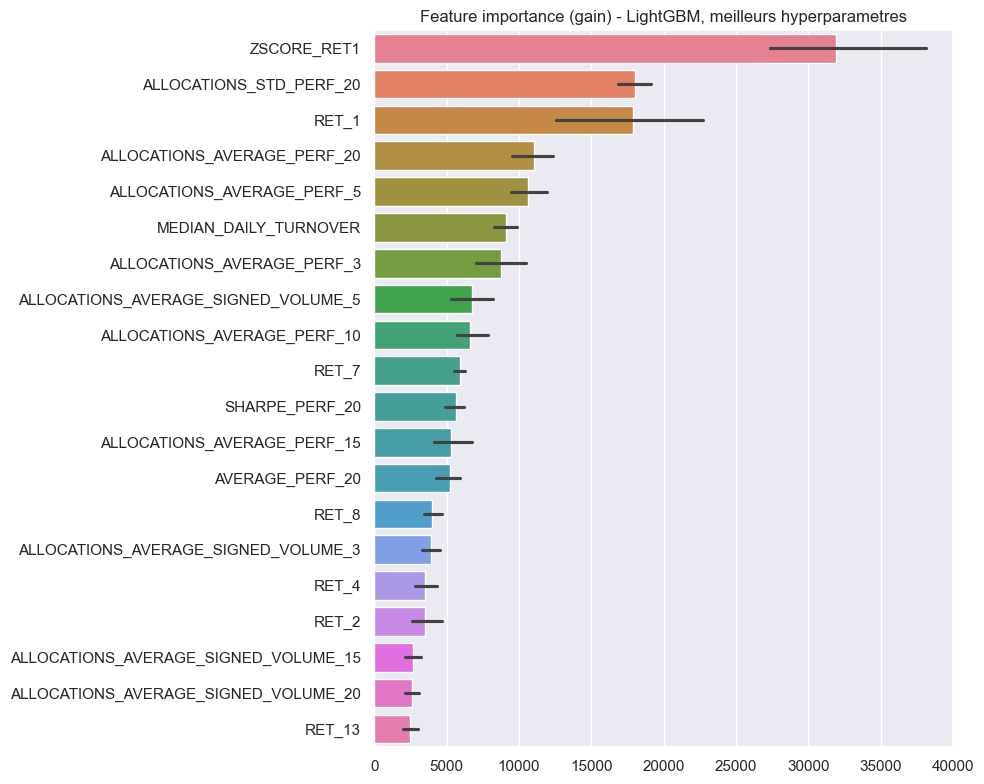

In [25]:
feature_importances = pd.DataFrame(
    [m.feature_importance(importance_type='gain') for m in models_lgbm_best],
    columns=features
)

feature_importances = feature_importances.loc[:, feature_importances.mean(0).sort_values(ascending=False).index[:20]]

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)
plt.title("Feature importance (gain) - LightGBM, meilleurs hyperparametres")
plt.tight_layout()
plt.show()


### Sélection de features par permutation importance

Avec désormais une centaine de features (dont plusieurs familles redondantes entre elles — momentum à
différents horizons, volume, forme de la distribution...), certaines n'apportent probablement rien au
modèle, voire ajoutent du bruit. Plutôt que de se fier uniquement à la feature importance "gain" (biaisée
vers les features à haute cardinalité), on mesure ici l'apport réel de chaque feature par **permutation**.

#### Fonction de permutation importance (sur LightGBM)

**Fonctionnement :** pour chaque fold et chaque feature, on mélange aléatoirement les valeurs de cette
feature dans les données de test du fold (en gardant toutes les autres colonnes intactes), puis on mesure
de combien l'accuracy du modèle (déjà entraîné pour ce fold) se dégrade par rapport à sa performance
normale. On répète le mélange 3 fois par feature pour lisser le bruit, puis on moyenne sur les 8 folds.

**Utilité :** si une feature est vraiment utile, casser son information (en la mélangeant) doit faire chuter
l'accuracy. Si l'accuracy ne bouge pas (ou s'améliore), la feature n'apporte rien au modèle — voire le
perturbe. Contrairement à la feature importance "gain" (vue plus haut), cette mesure n'est pas biaisée par
le nombre de valeurs distinctes d'une feature, et reflète directement l'impact sur la métrique du challenge.

**Apport au projet :** sert de base à la sélection de features de la cellule suivante — une feature avec une
importance par permutation négative ou nulle est une candidate à l'élimination.

In [26]:
def permutation_importance_lgbm(models, feat_list, n_repeats=3, random_state=42):
    rng = np.random.RandomState(random_state)
    importances = {f: [] for f in feat_list}

    for (local_train_dates_ids, local_test_dates_ids), model in zip(folds, models):
        local_test_dates = train_dates[local_test_dates_ids]
        local_test_ids = X_train['TS'].isin(local_test_dates)

        X_local_test = X_train.loc[local_test_ids, feat_list]
        y_local_test = (y_train.loc[local_test_ids, 'target'] > 0).astype(int)

        baseline_pred = model.predict(X_local_test.values, num_threads=N_THREADS)
        baseline_acc = accuracy_score(y_local_test, (baseline_pred > 0.5).astype(int))

        for feat in feat_list:
            drops = []
            for _ in range(n_repeats):
                X_shuffled = X_local_test.copy()
                X_shuffled[feat] = rng.permutation(X_shuffled[feat].values)
                shuffled_pred = model.predict(X_shuffled.values, num_threads=N_THREADS)
                shuffled_acc = accuracy_score(y_local_test, (shuffled_pred > 0.5).astype(int))
                drops.append(baseline_acc - shuffled_acc)
            importances[feat].append(np.mean(drops))

    return pd.Series({f: np.mean(v) for f, v in importances.items()}).sort_values(ascending=False)


perm_importances = permutation_importance_lgbm(models_lgbm_best, features, n_repeats=3)

print("Top 15 features (permutation importance) :")
print((perm_importances.head(15) * 100).round(3).astype(str) + " pt")
print("\nBottom 15 features (permutation importance) :")
print((perm_importances.tail(15) * 100).round(3).astype(str) + " pt")


Top 15 features (permutation importance) :
ZSCORE_RET1                             0.902 pt
RET_1                                   0.313 pt
MEDIAN_DAILY_TURNOVER                   0.193 pt
RET_7                                   0.127 pt
ALLOCATIONS_STD_PERF_20                 0.112 pt
ALLOCATIONS_AVERAGE_PERF_3              0.082 pt
RET_2                                   0.069 pt
TURNOVER_X_VOL                          0.054 pt
SHARPE_PERF_20                          0.054 pt
RET_9                                    0.05 pt
AVERAGE_PERF_20                          0.05 pt
ALLOCATIONS_AVERAGE_PERF_10             0.047 pt
ALLOCATIONS_AVERAGE_SIGNED_VOLUME_15    0.042 pt
SIGNED_VOLUME_1                         0.038 pt
RET_8                                   0.032 pt
dtype: object

Bottom 15 features (permutation importance) :
EWMA_PERF_HL10                          -0.002 pt
RET_16                                  -0.003 pt
SHARPE_PERF_5                           -0.003 pt
ALLOCATIONS

#### Sélection des features retenues

**Fonctionnement :** on ne garde que les features dont la permutation importance moyenne est strictement
positive (mélanger la feature dégrade vraiment l'accuracy) — les autres sont retirées.

**Utilité :** réduit le bruit et la dimensionnalité du problème en se basant sur une mesure directement
liée à la métrique du challenge, plutôt que de garder toutes les features par défaut.

**Apport au projet :** `selected_features` remplace `features` pour tout le reste du notebook (ré-entraînement
des modèles, stacking, soumission finale).

In [27]:
selected_features = perm_importances[perm_importances > 0].index.tolist()

print(f"Features conservees : {len(selected_features)} / {len(features)}")
print(f"Features retirees (importance <= 0, bruit ou redondance) : {len(features) - len(selected_features)}")


Features conservees : 57 / 87
Features retirees (importance <= 0, bruit ou redondance) : 30


#### Recalcul des prédictions out-of-fold sur les features sélectionnées

**Fonctionnement :** on refait **une seule** passe de cross-validation par modèle (8 folds, pas une
nouvelle grille d'hyperparamètres — on réutilise les meilleurs hyperparamètres déjà trouvés), mais cette
fois avec `selected_features` au lieu de `features`. Ça remplace les prédictions OOF et les modèles
précédents.

**Utilité :** garantit la cohérence entre les prédictions OOF utilisées pour entraîner le méta-modèle de
stacking et les features utilisées par les modèles finaux — sinon il y aurait un décalage entre ce sur quoi
le méta-modèle a appris et ce qu'il recevra en production.

**Apport au projet :** `oof_lgbm_best`/`oof_catboost_best`/`oof_xgboost_best` sont maintenant basés sur le
jeu de features réduit, prêts pour le stacking. Les nouveaux scores sont aussi ajoutés à `experiment_log`
pour comparer directement l'effet de la sélection de features.

In [28]:
scores_lgbm_reduced, oof_lgbm_best, models_lgbm_best = run_cv_lgbm(
    selected_features, lgbm_best_params, num_boost_round=500
)
lgbm_best_mean = np.mean(scores_lgbm_reduced) * 100
lgbm_best_std = np.std(scores_lgbm_reduced) * 100
print(f"LightGBM (features selectionnees): {lgbm_best_mean:.2f}% (+- {lgbm_best_std:.2f})")

scores_catboost_reduced, oof_catboost_best = run_cv_catboost(
    selected_features, catboost_best_params, iterations=500
)
catboost_best_mean = np.mean(scores_catboost_reduced) * 100
catboost_best_std = np.std(scores_catboost_reduced) * 100
print(f"CatBoost (features selectionnees): {catboost_best_mean:.2f}% (+- {catboost_best_std:.2f})")

scores_xgboost_reduced, oof_xgboost_best = run_cv_xgboost(
    selected_features, xgboost_best_params, n_estimators=500
)
xgboost_best_mean = np.mean(scores_xgboost_reduced) * 100
xgboost_best_std = np.std(scores_xgboost_reduced) * 100
print(f"XGBoost (features selectionnees): {xgboost_best_mean:.2f}% (+- {xgboost_best_std:.2f})")
gc.collect()

reduced_results = {
    'lightgbm_tuned_selected_features': (lgbm_best_mean, lgbm_best_std),
    'catboost_tuned_selected_features': (catboost_best_mean, catboost_best_std),
    'xgboost_tuned_selected_features': (xgboost_best_mean, xgboost_best_std),
}
experiment_log = pd.concat([
    experiment_log,
    pd.DataFrame([{'experiment': k, 'accuracy_mean': v[0], 'accuracy_std': v[1]} for k, v in reduced_results.items()])
]).sort_values('accuracy_mean', ascending=False).reset_index(drop=True)

experiment_log


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\2145525097.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.55975246 0.49428954 0.55165993 ... 0.53390686 0.52957754 0.4975157 ]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred


LightGBM (features selectionnees): 52.40% (+- 0.34)


C:\Users\jules\AppData\Local\Temp\ipykernel_28532\1075683613.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.54319392 0.48680427 0.53562418 ... 0.53016917 0.53090186 0.50117632]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  oof_proba.loc[X_local_test.index] = y_local_pred_proba


CatBoost (features selectionnees): 52.38% (+- 0.22)
XGBoost (features selectionnees): 52.39% (+- 0.36)


,experiment,accuracy_mean,accuracy_std
0,catboost_tuned,52.426216,0.258846
1,lightgbm_tuned_selected_features,52.399834,0.336612
2,xgboost_tuned_selected_features,52.394538,0.363625
3,catboost_tuned_selected_features,52.383518,0.218977
4,xgboost_tuned,52.342937,0.404977
5,lightgbm_tuned,52.309783,0.374633
6,linear_elasticnet,52.088322,0.341773
7,linear_logreg,52.075416,0.340953
8,naive_persistence_RET1,51.892432,NaN
9,naive_momentum_20j,50.822941,NaN


### Entraînement final des modèles de base (sur tout le train)

On entraîne LightGBM, CatBoost et XGBoost sur l'intégralité de `X_train`, avec les hyperparamètres choisis
par le tuning. Ces trois modèles alimentent le stacking ci-dessous.

#### LightGBM — entraînement final

**Fonctionnement :** ré-entraîne avec `lgbm_best_params` (issus du tuning) sur tout `X_train`, en utilisant
`selected_features` (après élimination des features inutiles par permutation importance).

**Apport au projet :** `preds_lgbm_proba` est l'une des 3 entrées du méta-modèle de stacking.

In [29]:
train_data_lgbm = lgbm.Dataset(X_train[selected_features], label=(y_train['target'] > 0).astype(int))
model_lgbm_final = lgbm.train(lgbm_best_params, train_data_lgbm, num_boost_round=500)
preds_lgbm_proba = model_lgbm_final.predict(X_test[selected_features])


#### CatBoost — entraînement final

**Fonctionnement :** même principe avec `catboost_best_params` et `selected_features`, `predict_proba` pour
les probabilités.

**Apport au projet :** `preds_catboost_proba`, 2e entrée du méta-modèle.

In [30]:
model_catboost_final = CatBoostClassifier(
    iterations=500, loss_function='Logloss', random_seed=42,
    verbose=False, thread_count=N_THREADS, **catboost_best_params,
)
model_catboost_final.fit(X_train[selected_features], (y_train['target'] > 0).astype(int))
preds_catboost_proba = model_catboost_final.predict_proba(X_test[selected_features])[:, 1]


#### XGBoost — entraînement final

**Fonctionnement :** même principe avec `xgboost_best_params` et `selected_features`.

**Apport au projet :** `preds_xgb_proba`, 3e et dernière entrée du méta-modèle.

In [31]:
model_xgb_final = xgb.XGBClassifier(
    n_estimators=500, objective='binary:logistic', eval_metric='logloss',
    random_state=42, n_jobs=N_THREADS, tree_method='hist', **xgboost_best_params,
)
model_xgb_final.fit(X_train[selected_features], (y_train['target'] > 0).astype(int))
preds_xgb_proba = model_xgb_final.predict_proba(X_test[selected_features])[:, 1]


### Stacking : méta-modèle à la place de la moyenne simple

Plutôt que de moyenner naïvement les 3 probabilités, on entraîne un **méta-modèle** (une régression
logistique très simple) qui apprend le meilleur poids à donner à chacun des 3 modèles de base, à partir de
leurs prédictions **out-of-fold** (non biaisées, voir plus haut).

#### Entraînement du méta-modèle

**Fonctionnement :** on assemble les 3 vecteurs de prédictions OOF (`oof_lgbm_best`,
`oof_catboost_best`, `oof_xgboost_best`) en un petit tableau à 3 colonnes (`meta_train`), puis on entraîne
une régression logistique dessus pour prédire le signe réel du target.

**Utilité :** un méta-modèle entraîné sur des prédictions **out-of-fold** apprend à combiner les modèles de
base sans avoir "vu" ces prédictions se former sur les mêmes données qu'il évalue — c'est ce qui rend le
stacking rigoureux plutôt qu'une simple moyenne arbitraire. Les coefficients appris indiquent quel modèle
de base pèse le plus dans la décision finale.

**Nuance honnête :** pour rester simple, l'accuracy du méta-modèle est ensuite mesurée sur ces mêmes
prédictions OOF qui ont servi à l'entraîner — une légère optimisme technique (pas de couche de validation
imbriquée supplémentaire pour le méta-modèle lui-même). Le risque réel est faible ici car le méta-modèle est
extrêmement simple (3 features, une régression logistique), donc peu capable de sur-apprendre.

**Apport au projet :** `meta_model` est ensuite appliqué aux prédictions test des 3 modèles finaux pour
produire la probabilité finale de la soumission.

In [32]:
meta_train = pd.DataFrame({
    'lgbm': oof_lgbm_best,
    'catboost': oof_catboost_best,
    'xgboost': oof_xgboost_best,
}, index=X_train.index).fillna(0.5)

meta_model = LogisticRegression()
meta_model.fit(meta_train, y_true)

print("Poids appris par le meta-modele :")
for name, coef in zip(meta_train.columns, meta_model.coef_[0]):
    print(f"  {name}: {coef:.3f}")


Poids appris par le meta-modele :
  lgbm: 1.687
  catboost: 1.525
  xgboost: 1.725


### Calibration du seuil de décision

**Fonctionnement :** plutôt que de couper à 0.5 par défaut, on cherche le seuil qui maximise l'accuracy sur
les prédictions **out-of-fold** du méta-modèle (jamais vues par ce dernier pendant son propre
entraînement direct sur le signe, donc une mesure raisonnablement fiable).

**Utilité :** si la distribution du target n'est pas parfaitement équilibrée 50/50 (vérifié dans l'EDA), le
seuil optimal peut légèrement différer de 0.5 — quelques dixièmes de point d'accuracy à gagner, sans aucun
risque puisqu'on ne change rien au modèle lui-même, juste la règle de décision finale.

**Apport au projet :** `optimal_threshold` est utilisé à la place de 0.5 pour binariser la prédiction
finale de la soumission.

In [33]:
def best_threshold(y_true_arr, y_proba, thresholds=np.linspace(0.3, 0.7, 41)):
    best_t, best_acc = 0.5, 0
    for t in thresholds:
        acc = accuracy_score(y_true_arr, (y_proba > t).astype(int))
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t, best_acc


meta_oof_proba = meta_model.predict_proba(meta_train)[:, 1]

acc_at_05 = accuracy_score(y_true, (meta_oof_proba > 0.5).astype(int))
optimal_threshold, optimal_threshold_acc = best_threshold(y_true, meta_oof_proba)

print(f"Accuracy OOF du stacking a seuil 0.5    : {acc_at_05*100:.2f}%")
print(f"Seuil optimal trouve : {optimal_threshold:.3f} -> accuracy OOF : {optimal_threshold_acc*100:.2f}%")


Accuracy OOF du stacking a seuil 0.5    : 52.42%
Seuil optimal trouve : 0.500 -> accuracy OOF : 52.42%


### Soumission finale (stacking + seuil calibré)

**Fonctionnement :** on applique le méta-modèle aux prédictions test des 3 modèles finaux
(`meta_test`), puis on binarise avec `optimal_threshold` (et non plus 0.5 fixe).

**Utilité :** combine à la fois l'apport du stacking (pondération apprise des 3 modèles) et celui de la
calibration de seuil, les deux améliorations demandées par rapport à la version précédente (moyenne simple
+ seuil fixe).

**Apport au projet :** `submission_final.csv` est le fichier à soumettre.

In [34]:
meta_test = pd.DataFrame({
    'lgbm': preds_lgbm_proba,
    'catboost': preds_catboost_proba,
    'xgboost': preds_xgb_proba,
}, index=X_test.index)

final_meta_proba = meta_model.predict_proba(meta_test)[:, 1]

submission_final = pd.DataFrame(
    (final_meta_proba > optimal_threshold).astype(int),
    index=sample_submission.index,
    columns=['target']
)
submission_final.to_csv('submission_final.csv')
submission_final.head()


,target
ROW_ID,
527073,0
527074,1
527075,0
527076,0
527077,0


#### Soumission LightGBM seul (référence, non soumise)

**Fonctionnement :** sauvegarde séparément les prédictions de LightGBM seul (meilleurs hyperparamètres,
seuil 0.5), dans un fichier distinct.

**Utilité :** permet de comparer *a posteriori*, une fois le score du leaderboard connu pour les deux
fichiers, si le stacking + la calibration de seuil ont réellement amélioré les choses par rapport à un seul
modèle simple.

**Apport au projet :** fichier de contrôle uniquement — ce n'est **pas** le fichier à soumettre en
priorité.

In [35]:
preds_lgbm_only = pd.DataFrame(
    (preds_lgbm_proba > 0.5).astype(int), index=sample_submission.index, columns=['target']
)
preds_lgbm_only.to_csv('preds_lgbm_only_reference.csv')


In [ ]:
perm_importances

ZSCORE_RET1                    0.009017
RET_1                          0.003134
MEDIAN_DAILY_TURNOVER          0.001935
RET_7                          0.001268
ALLOCATIONS_STD_PERF_20        0.001119
                                 ...   
RET_20                        -0.000087
AVERAGE_PERF_10               -0.000094
RET_17                        -0.000123
RET_3                         -0.000143
ALLOCATIONS_AVERAGE_PERF_20   -0.000178
Length: 87, dtype: float64